In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv("cardio_train.csv", sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,988,22469,1,155,69.0,130,80,2,2,0,0,1,0
1,989,14648,1,163,71.0,110,70,1,1,0,0,1,1
2,990,21901,1,165,70.0,120,80,1,1,0,0,1,0
3,991,14549,2,165,85.0,120,80,1,1,1,1,1,0
4,992,23393,1,155,62.0,120,80,1,1,0,0,1,0



| Cecha  | Grupa | Nazwa kolumny | Typ / Kodowanie | Uwagi |
|---|---|---|---|---|
| Age | Objective Feature | `age` | int (dni) | Wiek podany w dniach (można przeliczyć na lata: `age/365`) |
| Height | Objective Feature | `height` | int (cm) | Wzrost w centymetrach |
| Weight | Objective Feature | `weight` | float (kg) | Waga w kilogramach |
| Gender | Objective Feature | `gender` | kod kategoryczny | Zwykle 1–kobieta, 2–mężczyzna (zależnie od źródła) |
| Systolic blood pressure | Examination Feature | `ap_hi` | int | Ciśnienie skurczowe (mmHg) |
| Diastolic blood pressure | Examination Feature | `ap_lo` | int | Ciśnienie rozkurczowe (mmHg) |
| Cholesterol | Examination Feature | `cholesterol` | ordinal: 1/2/3 | 1–normal, 2–above normal, 3–well above normal |
| Glucose | Examination Feature | `gluc` | ordinal: 1/2/3 | 1–normal, 2–above normal, 3–well above normal |
| Smoking | Subjective Feature | `smoke` | binarne: 0/1 | 0–nie, 1–tak |
| Alcohol intake | Subjective Feature | `alco` | binarne: 0/1 | 0–nie, 1–tak |
| Physical activity | Subjective Feature | `active` | binarne: 0/1 | 0–nie, 1–tak |
| Presence of CVD | Target Variable | `cardio` | binarne: 0/1 | 0–brak choroby, 1–choroba obecna |


In [67]:
# Sprawdzenie brakujących wartości
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [68]:
# Ustalmy typy zmiennych 
continuous_features = ["age", "height", "weight", "ap_hi", "ap_lo"]
categorical_features = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]

In [69]:
# Zmieniamy jednostki wieku (z dni na lata)
df["age_years"] = (df["age"] / 365).astype(int)
continuous_features.remove("age")
continuous_features.append("age_years")

In [70]:
# Wartości minimalne i maksymalne zmiennych ciągłych
for col in continuous_features:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col:>10} | min: {min_val:>8} | max: {max_val:>8}")

    height | min:       55 | max:      250
    weight | min:     10.0 | max:    200.0
     ap_hi | min:     -150 | max:    16020
     ap_lo | min:      -70 | max:    11000
 age_years | min:       29 | max:       64


In [71]:
# Czyszczenie danych – usunięcie błędnych wartości
# Dzięki temu pozbywamy się błędów pomiarowych (np. ujemnych ciśnień czy wzrostu 55 cm).
# Przedziały zostały podparte wiedzeniami z literatury medycznej

before = len(df)

# Filtrowanie danych do realistycznych zakresów
df = df[
    df["height"].between(110, 230) &
    df["weight"].between(35, 200) &
    df["ap_hi"].between(50, 180) &
    df["ap_lo"].between(40, 120)
]

# Liczba rekordów po czyszczeniu
after = len(df)
removed = before - after

print(f" Rekordy przed czyszczeniem: {before}")
print(f" Rekordy po czyszczeniu:     {after}")
print(f" Usunięto rekordów:          {removed}")

 Rekordy przed czyszczeniem: 69301
 Rekordy po czyszczeniu:     67685
 Usunięto rekordów:          1616


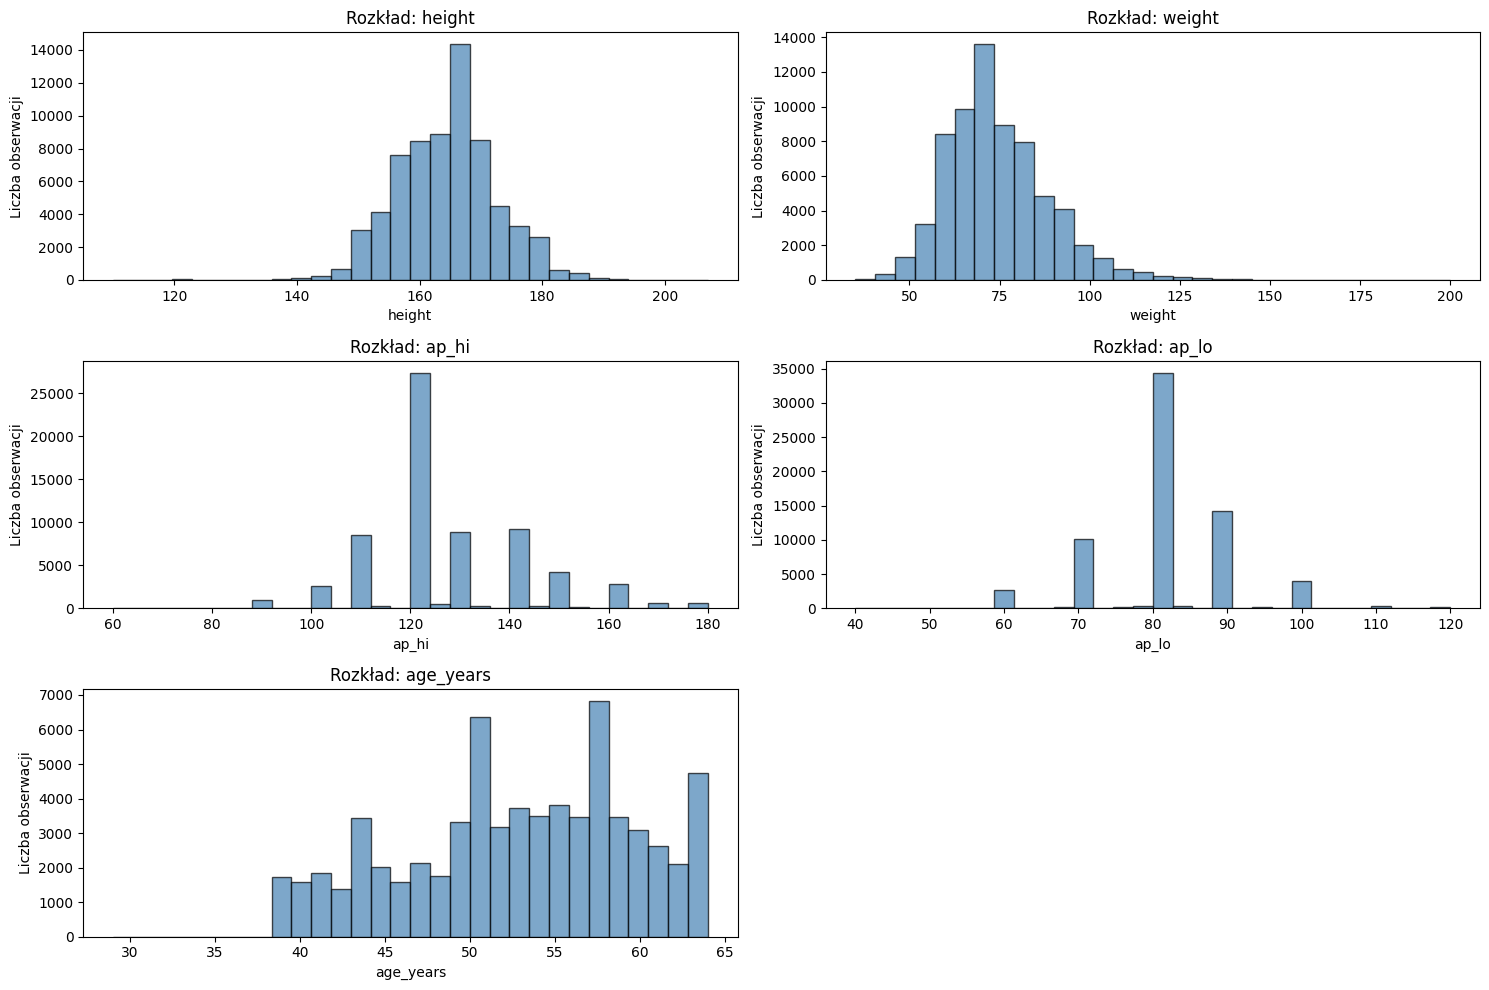

In [72]:
# Wykresy histogramów zmiennych ciągłych
plt.figure(figsize=(15, 10))

for i, col in enumerate(continuous_features, 1):
    plt.subplot(3, 2, i)
    plt.hist(df[col], bins = 30, color="steelblue", edgecolor="black", alpha=0.7)
    plt.title(f"Rozkład: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczba obserwacji")

plt.tight_layout()
plt.show()

In [73]:
# Dyskretyzacja zmiennych ciągłych
df["age_group"] = pd.cut(df["age_years"], bins=[29, 40, 50, 60, 70], labels=["29–39", "40–49", "50–59", "60–69"])
df["height_group"] = pd.cut(df["height"], bins = [110, 150, 160, 170, 180, 190, 200, 230], labels = ["110–150", "150–160", "160–170", "170–180", "180–190", "190–200", "200–230"])
df["weight_group"] = pd.cut(df["weight"], bins= [35, 50, 60, 70, 80, 90, 100, 120, 150, 200], labels = ["35–50", "50–60", "60–70", "70–80", "80–90", "90–100", "100–120", "120–150", "150–200"])
df["ap_hi_group"] = pd.cut(df["ap_hi"], bins= [50, 90, 120, 130, 140, 160, 180], labels = ["50–90", "90–120", "120–130", "130–140", "140–160", "160–180"])
df["ap_lo_group"] = pd.cut(df["ap_lo"], bins= [40, 60, 80, 85, 90, 100, 120], labels = ["40–60", "60–80", "80–85", "85–90", "90–100", "100–120"])

In [74]:
discrete_features = ["age_group", "height_group", "weight_group", "ap_hi_group", "ap_lo_group"]
for col in discrete_features:
    df[col] = df[col].cat.codes
all_features = discrete_features + categorical_features
df[all_features].head()   

,age_group,height_group,weight_group,ap_hi_group,ap_lo_group,gender,cholesterol,gluc,smoke,alco,active,cardio
0,3,1,2,2,1,1,2,2,0,0,1,0
1,0,2,3,1,1,1,1,1,0,0,1,1
2,2,2,2,1,1,1,1,1,0,0,1,0
3,0,2,4,1,1,2,1,1,1,1,1,0
4,3,1,2,1,1,1,1,1,0,0,1,0


In [75]:
df_to_save = df[all_features]
df_to_save.to_csv("cardio_cleaned.csv", index=False)